# s1000_400f-Slice — Selector-Vergleich (amtown03, frames 1000..1399)

Eigener Loader auf `output/s1000_400f_results.csv`. Analog zum `s3100_200f`-Notebook,
aber für den 400-Frame-Slice ab Frame 1000.

**Sweep-Stand (2026-05-27):** 37 OK / 12 FAIL (alle `rc=137` = VRAM-Watchdog-Kill bei
~8 GiB GPU). Failed-Configs sind aggressive Selektoren mit hoher Map-Rate
(`coko_a005`, alle 4 `aim`-Varianten, `game_th030`, alle 3 `nurbs`-Varianten) und
die `skip_no_filter`-Pfade mit niedrigem `skip` (1/2/3) — alle laufen in den
gleichen ~9 GiB Peak-VRAM, weil ungezügeltes Mapping bei langem Slice die
Gaussian-Anzahl + Buffer/Storage-Manager überschreiten lässt.

Inhalt:
1. Fail-Analyse (Tabelle: was, warum, wann gekillt)
2. Bar-Charts: Variant × (Laufzeit, PSNR, Mapped-KFs)
3. Pareto: Laufzeit ↔ PSNR
4. Scatter: Laufzeit ↔ Mapped-KFs
5. Scatter: PSNR ↔ Mapped-KFs
6. Per-Frame-Konsens
7. Per-Selektor-Grid — welche Frames hat jeder Algorithmus gemappt?


In [12]:
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# Wie scripts/log_sweep_row.py — finditer pro Zeile (tqdm-Escapes).
_KF_LINE_RX = re.compile(rb"\[\s*(\d+)\]\s+kf=([YNS])")


def parse_mapped_frames(log_path: Path) -> np.ndarray:
    """Frame-Indizes mit kf=Y (Selector-Accept → Mapper) aus run_*.log."""
    if not log_path.exists():
        return np.array([], dtype=np.int64)
    frames = []
    with open(log_path, "rb") as f:
        for raw in f:
            for m in _KF_LINE_RX.finditer(raw):
                if m.group(2) == b"Y":
                    frames.append(int(m.group(1)))
    return np.asarray(frames, dtype=np.int64)


In [13]:
REPO = Path('/home/philipp/Dokumente/Github/VINGS-Mono-BA')

CSV_S1000 = REPO / 'output' / 's1000_400f_results.csv'
df_raw = pd.read_csv(CSV_S1000)
df_raw = df_raw.sort_values('timestamp_start').drop_duplicates(['variant'], keep='last').reset_index(drop=True)
print(f'Total runs (latest per variant): {len(df_raw)}')
print('Status counts:')
print(df_raw['status'].value_counts())


Total runs (latest per variant): 49
Status counts:
status
OK      37
FAIL    12
Name: count, dtype: int64


## 1) Fail-Analyse — alle 12 Failures sind VRAM-Kills

`rc=137` = SIGKILL durch den User-Watchdog (`feedback_vram_watchdog.md`) wenn ein Run
~8 GiB GPU überschreitet. Wir tabellieren Peak-VRAM, wo (Frame-Index) gekillt wurde
und wie viele KFs der Mapper bis dahin gefressen hat.


In [14]:
df_fail = df_raw[df_raw['status'] != 'OK'].copy()

def last_kf_seen(log_path):
    if not isinstance(log_path, str) or not Path(log_path).exists():
        return (-1, -1)
    last_frame = -1; last_y = -1
    with open(log_path, 'rb') as f:
        for raw in f:
            for m in _KF_LINE_RX.finditer(raw):
                fr = int(m.group(1))
                last_frame = max(last_frame, fr)
                if m.group(2) == b'Y':
                    last_y = max(last_y, fr)
    return (last_frame, last_y)

rows = []
for _, r in df_fail.iterrows():
    last_fr, last_y = last_kf_seen(r['log_path'])
    rows.append(dict(
        variant=r['variant'], group=r['group'],
        peak_vram_mib=r['peak_vram_mib'], peak_ram_gb=r['peak_ram_gb'],
        duration_min=r['duration_min'], exit_code=r['exit_code'],
        last_frame_seen=last_fr, last_kf_Y=last_y,
        n_mapped_at_kill=r['n_mapped'], psnr_partial=r['psnr'],
    ))
fail_tbl = pd.DataFrame(rows).sort_values('peak_vram_mib', ascending=False)
print('Failed runs (rc=137 = VRAM-Watchdog @ ~8 GiB):')
print(fail_tbl.to_string(index=False))


Failed runs (rc=137 = VRAM-Watchdog @ ~8 GiB):
        variant          group  peak_vram_mib  peak_ram_gb  duration_min  exit_code  last_frame_seen  last_kf_Y  n_mapped_at_kill  psnr_partial
      coko_a005           coko           9746         1.99          3.05          1              212        212                65       22.3839
     aim_ovl085            aim           9675         2.00          3.30          1              138        138                76       22.0348
     aim_ovl055            aim           9642         2.00          3.35          1              154        153                71       23.0844
     game_th030           game           9592         2.00          3.05          1              245        241                58       20.9246
     nurbs_sec1          nurbs           9482         2.00          3.70          1              195        192                76       21.9839
nofilter_skip_2 skip_no_filter           9481         1.90          2.22          1      

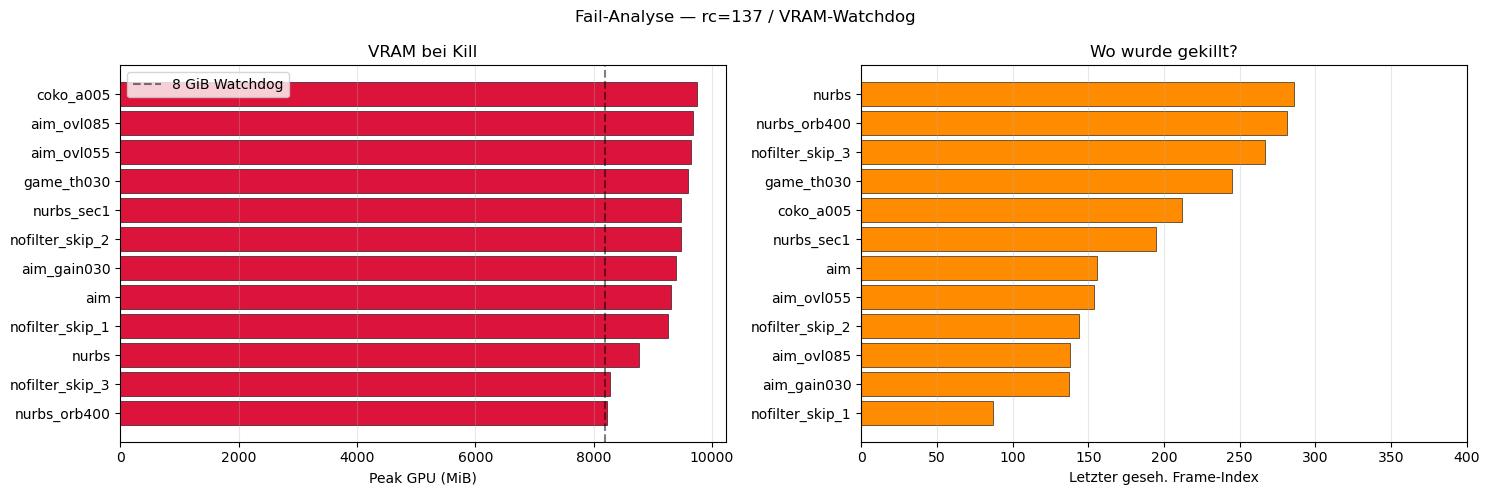

In [15]:
# Visualisierung: VRAM-Peak pro Failure vs. Where (Frame-Index) it died
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
order = fail_tbl.sort_values('peak_vram_mib').reset_index(drop=True)
ax.barh(order['variant'], order['peak_vram_mib'], color='crimson', edgecolor='black', linewidth=0.4)
ax.axvline(8192, color='black', ls='--', alpha=0.5, label='8 GiB Watchdog')
ax.set_xlabel('Peak GPU (MiB)'); ax.set_title('VRAM bei Kill')
ax.grid(alpha=0.3, axis='x'); ax.legend()

ax = axes[1]
order = fail_tbl.sort_values('last_frame_seen').reset_index(drop=True)
ax.barh(order['variant'], order['last_frame_seen'], color='darkorange', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Letzter geseh. Frame-Index'); ax.set_title('Wo wurde gekillt?')
ax.set_xlim(0, 400); ax.grid(alpha=0.3, axis='x')

fig.suptitle('Fail-Analyse — rc=137 / VRAM-Watchdog')
fig.tight_layout(); plt.show()


In [16]:
# Filter auf OK-Runs für die restlichen Plots.
df_s1000 = df_raw[df_raw['status'] == 'OK'].reset_index(drop=True)
print(f'OK runs: {len(df_s1000)}')
print(df_s1000.groupby('group').size())


OK runs: 37
group
adaptive_kf       4
baseline          1
coko              3
game              3
mapskip           6
mm3dgs            4
nurbs             1
orbslam           4
skip_no_filter    3
two_gate          4
vista             4
dtype: int64


## 2) Bar-Charts pro Variant — Laufzeit, PSNR, Mapped-KFs

Sortiert pro Gruppe; Farbe = Gruppe. `vings_filter`-Baseline ist als Referenz mit dabei.


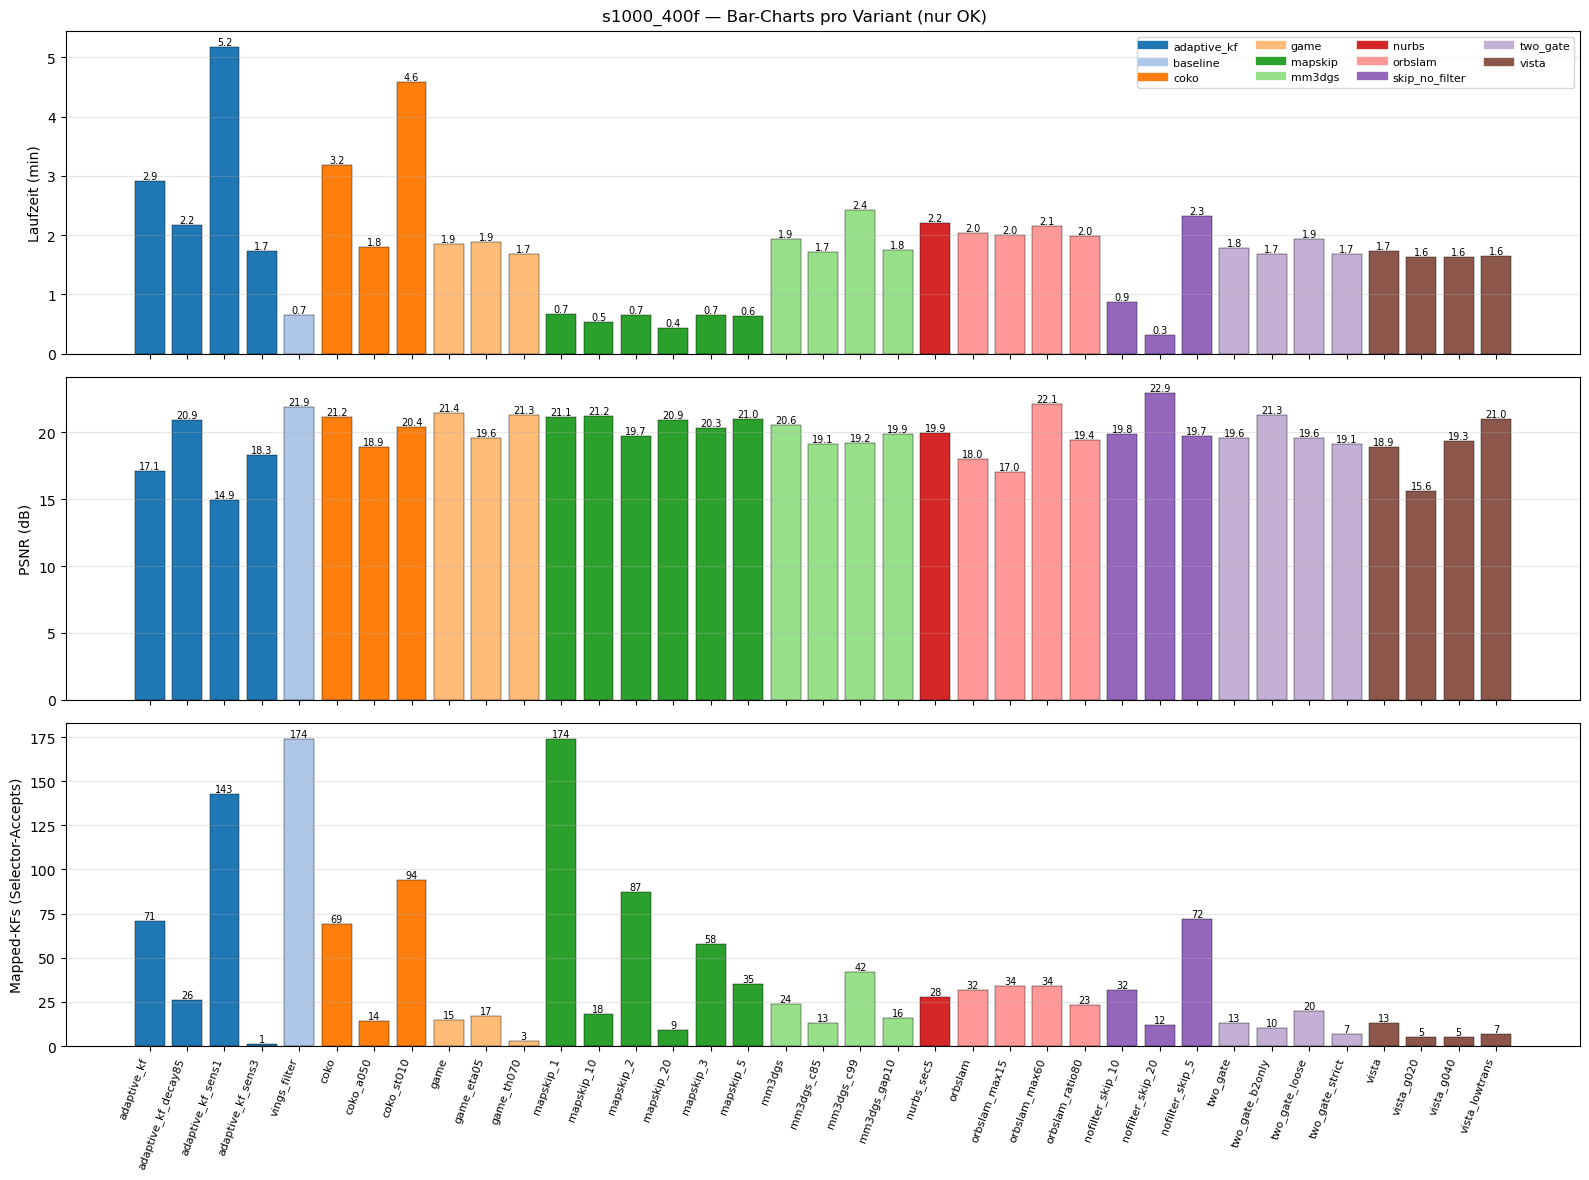

In [17]:
GROUPS = sorted(df_s1000['group'].unique())
GROUP_COLOR = dict(zip(GROUPS, plt.cm.tab20.colors[:len(GROUPS)]))

df_plot = df_s1000.sort_values(['group','variant']).reset_index(drop=True)
labels  = df_plot['variant'].tolist()
colors  = [GROUP_COLOR[g] for g in df_plot['group']]
x = np.arange(len(labels))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
metrics = [
    ('duration_min', 'Laufzeit (min)', axes[0]),
    ('psnr',         'PSNR (dB)',       axes[1]),
    ('n_mapped',     'Mapped-KFs (Selector-Accepts)', axes[2]),
]
for col, ylabel, ax in metrics:
    ax.bar(x, df_plot[col], color=colors, edgecolor='black', linewidth=0.3)
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3, axis='y')
    for xi, v in zip(x, df_plot[col]):
        ax.text(xi, v, f'{v:.1f}' if col != 'n_mapped' else f'{int(v)}', ha='center', va='bottom', fontsize=7)

axes[-1].set_xticks(x); axes[-1].set_xticklabels(labels, rotation=70, ha='right', fontsize=8)
legend_handles = [Line2D([0],[0], color=GROUP_COLOR[g], lw=6, label=g) for g in GROUPS]
axes[0].legend(handles=legend_handles, loc='upper right', ncol=4, fontsize=8)
fig.suptitle('s1000_400f — Bar-Charts pro Variant (nur OK)', fontsize=12)
fig.tight_layout(); plt.show()


## 3) Pareto-Front — PSNR vs Laufzeit

Mapskip- und skip_no_filter-Gruppen werden vor dem Pareto-Vergleich entfernt
(unterschiedliche Spielregel: kein Selector-Algo).


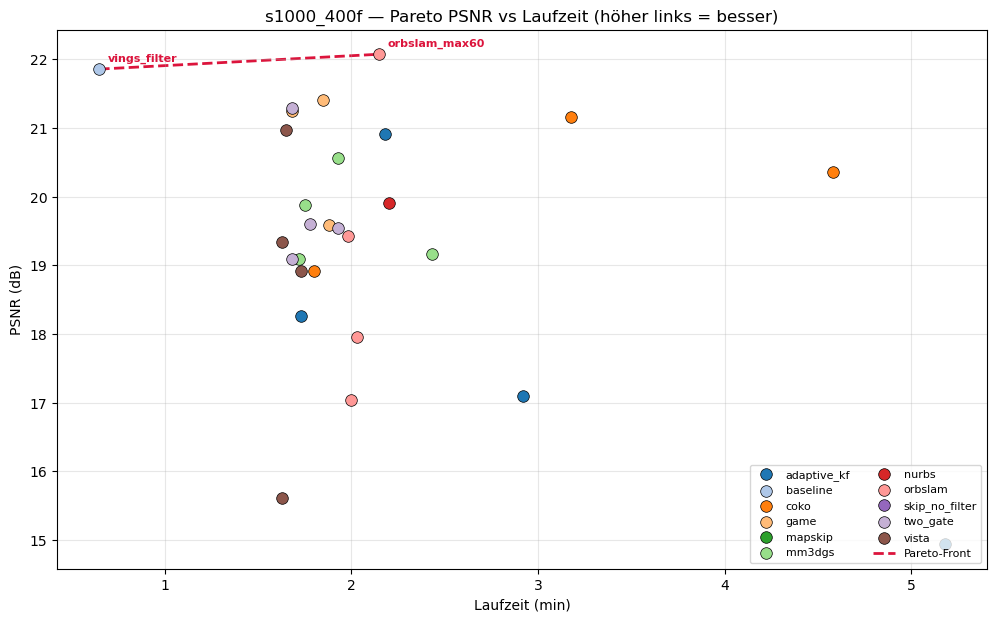

Pareto-Front (kürzeste Laufzeit → höchster PSNR):
   group       variant  duration_min    psnr  n_mapped  n_metric_frames
baseline  vings_filter          0.65 21.8579       174               15
 orbslam orbslam_max60          2.15 22.0747        34               34


In [18]:
def pareto_front(df, x='duration_min', y='psnr'):
    s = df.sort_values(x).reset_index(drop=True)
    best = -np.inf; mask = []
    for v in s[y]:
        if v > best:
            mask.append(True); best = v
        else:
            mask.append(False)
    s['on_front'] = mask
    return s

df_s1000 = df_s1000[~df_s1000['group'].isin(['mapskip', 'skip_no_filter'])].copy()

pf = pareto_front(df_s1000, 'duration_min', 'psnr')
front = pf[pf['on_front']].sort_values('duration_min')

fig, ax = plt.subplots(figsize=(12, 7))
for g in GROUPS:
    sub = pf[pf['group']==g]
    ax.scatter(sub['duration_min'], sub['psnr'], s=70, color=GROUP_COLOR[g], label=g, edgecolor='black', linewidth=0.5, zorder=2)
ax.plot(front['duration_min'], front['psnr'], color='crimson', lw=2, ls='--', zorder=1, label='Pareto-Front')
for _, r in front.iterrows():
    ax.annotate(r['variant'], (r['duration_min'], r['psnr']),
                xytext=(6, 6), textcoords='offset points', fontsize=8, color='crimson', fontweight='bold')
ax.set_xlabel('Laufzeit (min)'); ax.set_ylabel('PSNR (dB)')
ax.set_title('s1000_400f — Pareto PSNR vs Laufzeit (höher links = besser)')
ax.grid(alpha=0.3); ax.legend(loc='lower right', ncol=2, fontsize=8)
plt.show()

print('Pareto-Front (kürzeste Laufzeit → höchster PSNR):')
print(front[['group','variant','duration_min','psnr','n_mapped','n_metric_frames']].to_string(index=False))


## 4) Scatter — Laufzeit vs Mapped-KFs

Sanity-Check: lineare Beziehung erwartet (jeder Mapper-Run kostet ~0.7–1.0 s).
Outlier = Selektor mit hohem Overhead pro Frame (z. B. DINOv2 in `coko_slam`).


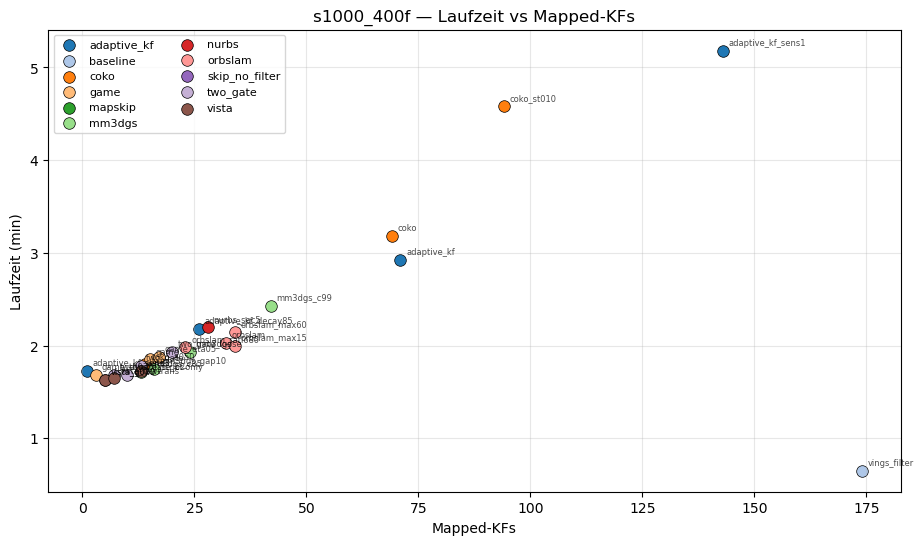

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
for g in GROUPS:
    sub = df_s1000[df_s1000['group']==g]
    ax.scatter(sub['n_mapped'], sub['duration_min'], s=70, color=GROUP_COLOR[g], label=g, edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['variant'], (r['n_mapped'], r['duration_min']),
                    xytext=(4, 4), textcoords='offset points', fontsize=6, alpha=0.7)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('Laufzeit (min)')
ax.set_title('s1000_400f — Laufzeit vs Mapped-KFs')
ax.grid(alpha=0.3); ax.legend(loc='best', ncol=2, fontsize=8)
plt.show()


## 5) Scatter — PSNR vs Mapped-KFs

Sättigt PSNR ab einer KF-Anzahl?


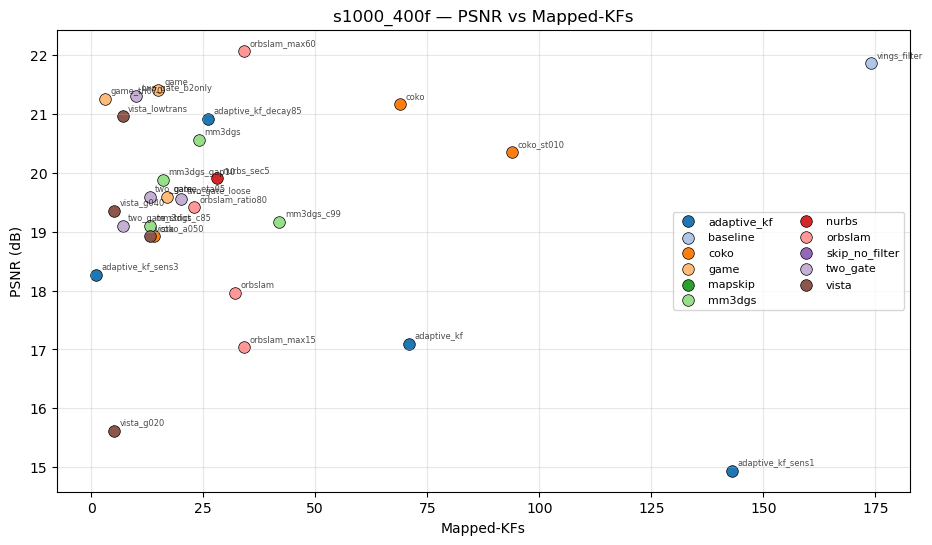

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
for g in GROUPS:
    sub = df_s1000[df_s1000['group']==g]
    ax.scatter(sub['n_mapped'], sub['psnr'], s=70, color=GROUP_COLOR[g], label=g, edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['variant'], (r['n_mapped'], r['psnr']),
                    xytext=(4, 4), textcoords='offset points', fontsize=6, alpha=0.7)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('PSNR (dB)')
ax.set_title('s1000_400f — PSNR vs Mapped-KFs')
ax.grid(alpha=0.3); ax.legend(loc='best', ncol=2, fontsize=8)
plt.show()


## 6) Per-Frame-Konsens

Pro Frame-Index 0..399: wie viele Selektor-Variants haben `kf=Y` gesetzt.
Nur Selektoren (kein mapskip / skip_no_filter / baseline).


Selector runs: 28


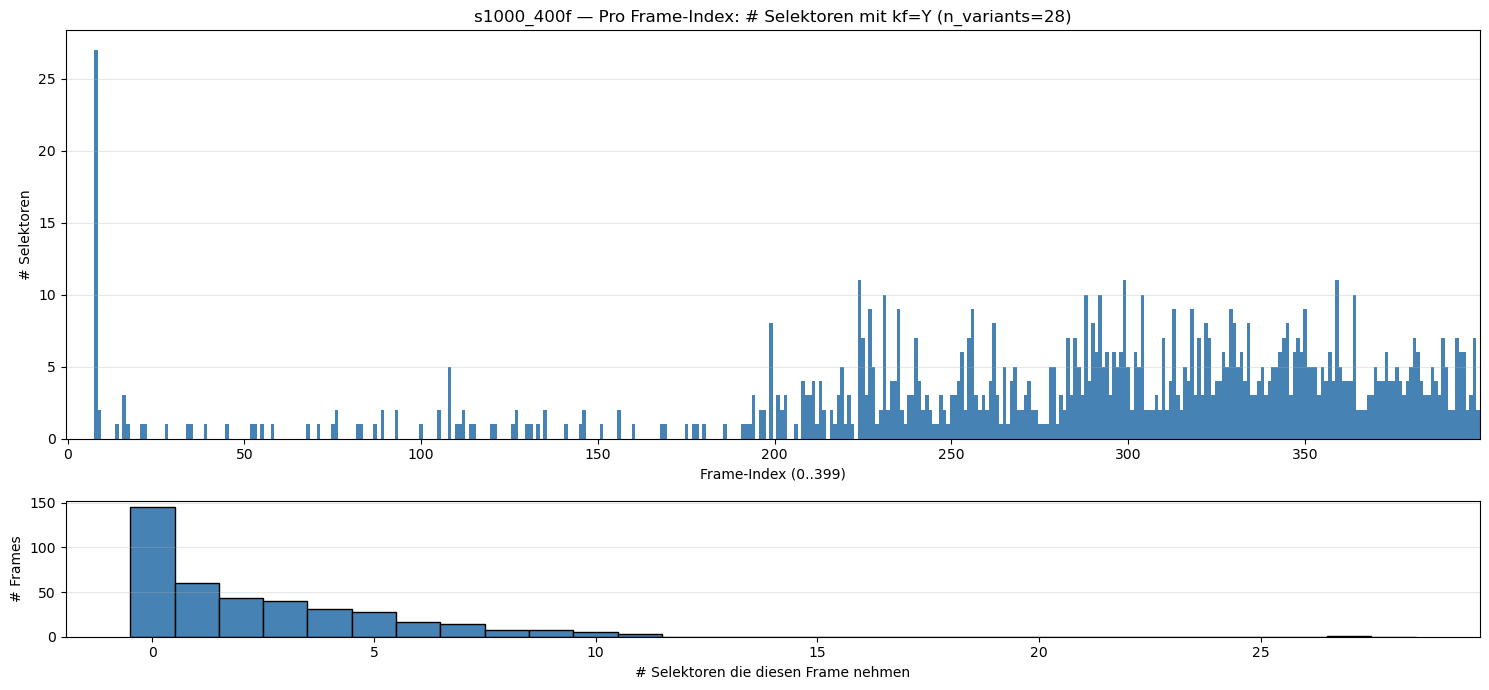

Top-10 Konsens-Frames:
  frame   8: 27 Selektoren
  frame 359: 11 Selektoren
  frame 299: 11 Selektoren
  frame 224: 11 Selektoren
  frame 288: 10 Selektoren
  frame 364: 10 Selektoren
  frame 292: 10 Selektoren
  frame 304: 10 Selektoren
  frame 231: 10 Selektoren
  frame 235: 9 Selektoren


In [21]:
SELECTOR_ONLY = df_s1000[~df_s1000['group'].isin(['mapskip','skip_no_filter'])].copy()
print(f'Selector runs: {len(SELECTOR_ONLY)}')

frames_by_variant = {}
for _, r in SELECTOR_ONLY.iterrows():
    if pd.isna(r['log_path']):
        continue
    arr = parse_mapped_frames(Path(r['log_path']))
    if len(arr) == 0:
        continue
    frames_by_variant[r['variant']] = np.unique(arr)

N = 400
consensus = np.zeros(N, dtype=np.int32)
for v, frames in frames_by_variant.items():
    valid = frames[frames < N]
    consensus[valid] += 1

fig, axes = plt.subplots(2, 1, figsize=(15, 7), gridspec_kw={'height_ratios':[3,1]})
axes[0].bar(np.arange(N), consensus, width=1.0, color='steelblue', edgecolor='none')
axes[0].set_title(f's1000_400f — Pro Frame-Index: # Selektoren mit kf=Y (n_variants={len(frames_by_variant)})')
axes[0].set_xlabel('Frame-Index (0..399)'); axes[0].set_ylabel('# Selektoren')
axes[0].set_xlim(-0.5, N-0.5); axes[0].grid(alpha=0.3, axis='y')

bins = np.arange(0, len(frames_by_variant)+2) - 0.5
axes[1].hist(consensus, bins=bins, color='steelblue', edgecolor='black')
axes[1].set_xlabel('# Selektoren die diesen Frame nehmen'); axes[1].set_ylabel('# Frames')
axes[1].grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

# Tabelle: Top-Consensus-Frames
top = np.argsort(-consensus)[:10]
print('Top-10 Konsens-Frames:')
for idx in top:
    print(f'  frame {idx:3d}: {consensus[idx]} Selektoren')


## 6) Per-Selektor-Grid — welche Frames hat jeder Algorithmus gemappt?

Ein kleines Subplot pro Selektor-Variant. X-Achse = Frame-Index (0..399),
Y-Achse = 1 wenn der Selektor diesen Frame an den Mapper gegeben hat (`kf=Y`), sonst 0.
Hilft zu sehen *wo* in der Sequenz ein Algorithmus dicht/sparsam selektiert.


Variants in grid: 28


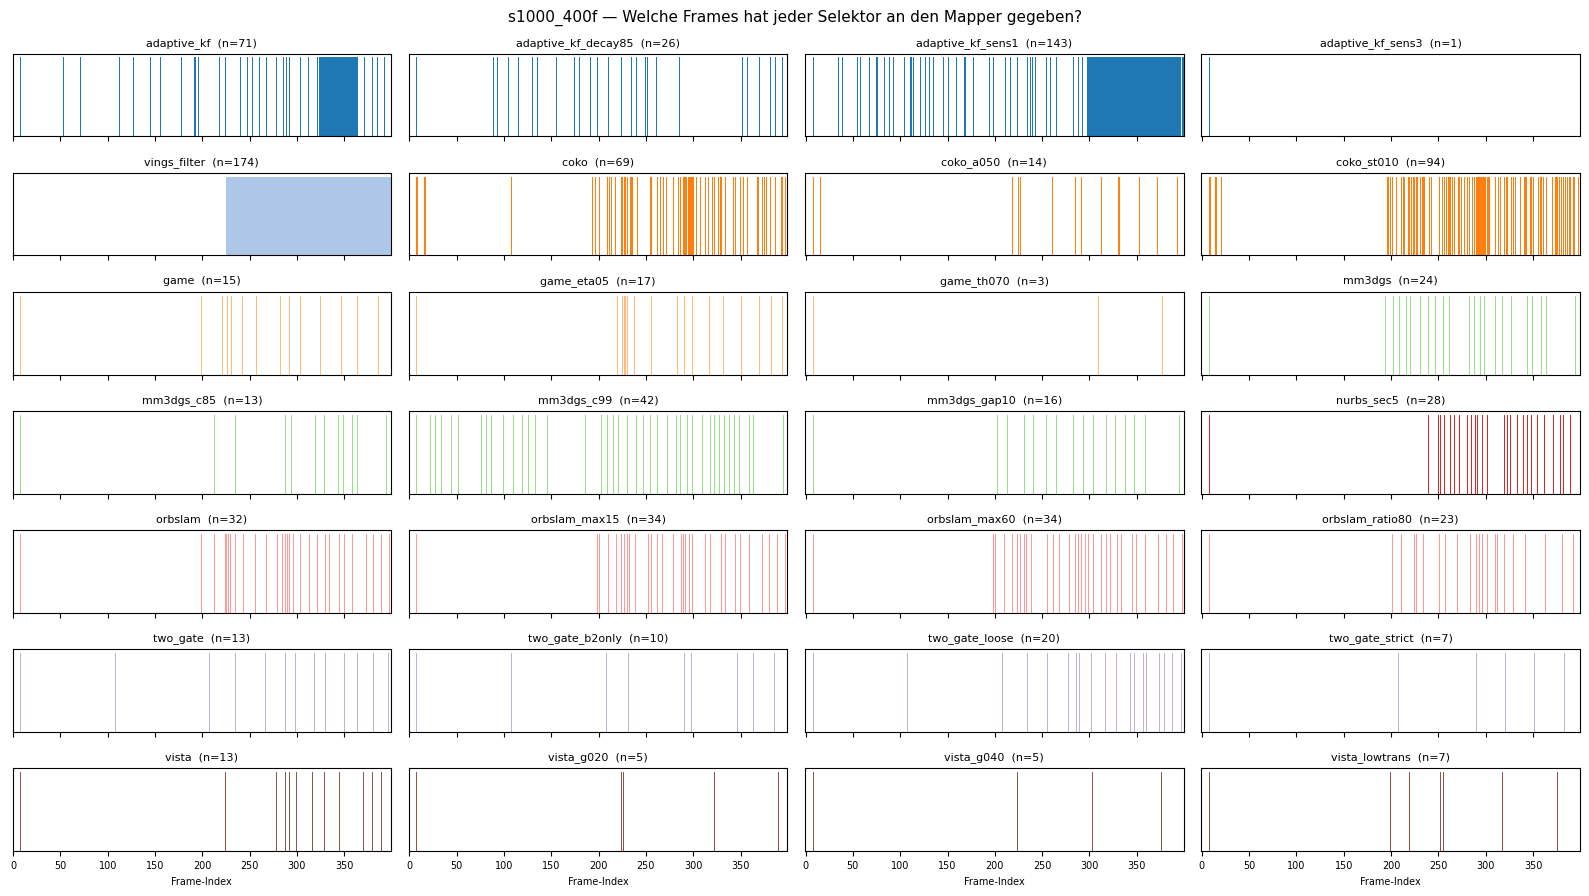

In [22]:
import math

# Re-use frames_by_variant_s from previous cell (s3100) / frames_by_variant from s1000 nb.
fbv = frames_by_variant
N   = 400

# Sort variants by group then name for nicer layout.
df_sel = df_s1000[~df_s1000['group'].isin(['mapskip','skip_no_filter'])]
ordered = (df_sel.sort_values(['group','variant'])['variant'].tolist())
variants = [v for v in ordered if v in fbv]
print(f'Variants in grid: {len(variants)}')

ncols = 4
nrows = math.ceil(len(variants) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.0, nrows*1.3), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

var_to_group = dict(zip(df_s1000['variant'], df_s1000['group']))

for ax, v in zip(axes, variants):
    frames = fbv[v]
    mask = np.zeros(N, dtype=np.int8)
    valid = frames[frames < N]
    mask[valid] = 1
    g = var_to_group.get(v, 'sel')
    col = GROUP_COLOR.get(g, 'steelblue')
    ax.bar(np.arange(N), mask, width=1.0, color=col, edgecolor='none')
    ax.set_title(f'{v}  (n={int(mask.sum())})', fontsize=8)
    ax.set_ylim(0, 1.05); ax.set_yticks([])
    ax.set_xlim(-0.5, N-0.5)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(False)

# Hide unused subplots
for ax in axes[len(variants):]:
    ax.axis('off')

for ax in axes[-ncols:]:
    ax.set_xlabel('Frame-Index', fontsize=7)

fig.suptitle('s1000_400f — Welche Frames hat jeder Selektor an den Mapper gegeben?', fontsize=11)
fig.tight_layout()
plt.show()
